In [65]:
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
import numpy as np
import seaborn as sns

In [268]:
cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/*/output_case*.csv"))
confidence_cases=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/*/confidence_case*.csv"))
imus=sorted(glob("/home/*/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/*/output_IMU*.csv"))
gt=sorted(glob("/home/saab/Desktop/2024_UWR/Analysis/gt/13*/*1302.csv"))
print(cases)
print(confidence_cases)
print(imus)
print(gt)

['/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition10_1_2026_04_02_15_43_08.bag/output_case_Condition10_1_2026_04_02_15_43_08.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition10_2026_04_02_15_35_57.bag/output_case_Condition10_2026_04_02_15_35_57.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition11_2026_04_02_15_47_28.bag/output_case_Condition11_2026_04_02_15_47_28.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition12_2026_04_02_15_54_25.bag/output_case_Condition12_2026_04_02_15_54_25.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition13_2026_04_02_16_02_05.bag/output_case_Condition13_2026_04_02_16_02_05.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition15_2026_04_02_16_13_14.bag/output_case_Condition15_2026_04_02_16_13_14.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/

In [58]:
trial=pd.read_csv(imus[-1])
trial

,Timestamp,IMU_Linear_Acc_X,IMU_Linear_Acc_Y,IMU_Linear_Acc_Z,Filtered_X,Filtered_Y,Filtered_Z,Pose_X,Pose_Y,Pose_Z
0,1.731474e+09,-0.350347,0.429062,-9.984730,-0.000007,-0.000025,0.000012,-3.440671e-10,-1.083666e-09,5.192533e-10
1,1.731474e+09,-0.339837,0.433676,-9.985616,-0.000010,-0.000039,0.000019,-4.613177e-10,-1.491472e-09,7.156067e-10
2,1.731474e+09,-0.342528,0.416920,-9.980188,-0.000013,-0.000058,0.000028,-7.707537e-10,-2.642711e-09,1.269468e-09
3,1.731474e+09,-0.341301,0.424089,-9.983532,-0.000017,-0.000081,0.000039,-9.386267e-10,-3.298206e-09,1.584532e-09
4,1.731474e+09,-0.334915,0.421203,-9.987563,-0.000022,-0.000110,0.000053,-1.322463e-09,-4.878625e-09,2.343593e-09
...,...,...,...,...,...,...,...,...,...,...
832,1.731474e+09,-0.394337,0.536361,-9.969599,-0.023809,-0.161622,0.006744,2.481599e+00,-6.358276e+00,2.549665e+00
833,1.731474e+09,-0.388038,0.522212,-9.993153,-0.023494,-0.167361,0.007046,2.488138e+00,-6.427945e+00,2.556658e+00
834,1.731474e+09,-0.429037,0.492338,-10.006981,-0.023092,-0.173257,0.007340,2.494520e+00,-6.497000e+00,2.563564e+00
835,1.731474e+09,-0.402917,0.442817,-9.997652,-0.022601,-0.179279,0.007623,2.500792e+00,-6.565920e+00,2.570432e+00


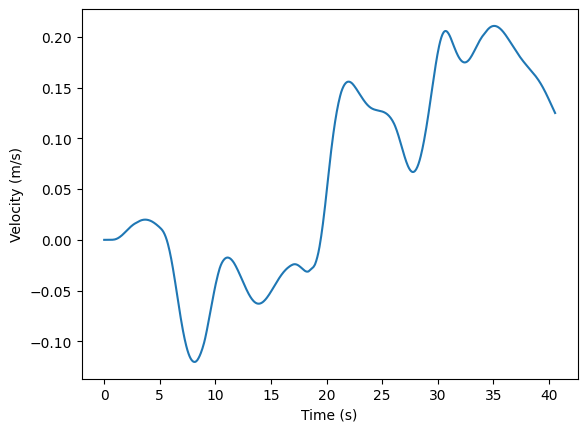

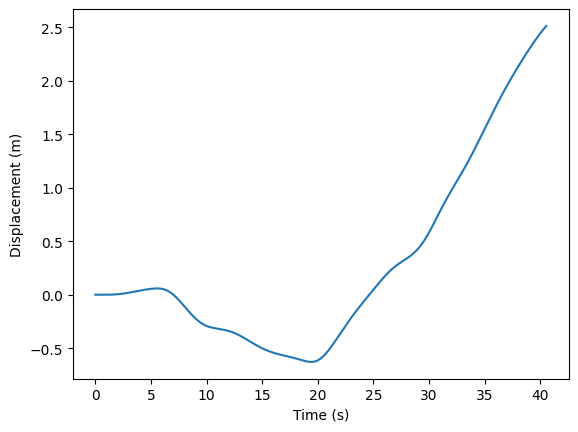

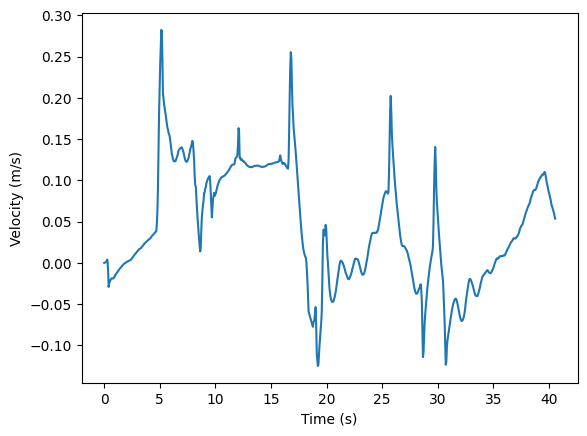

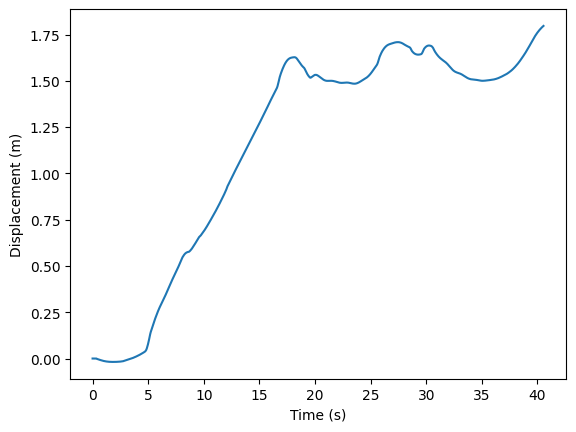

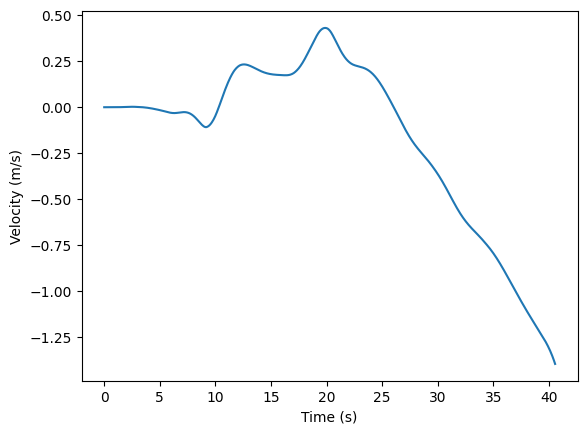

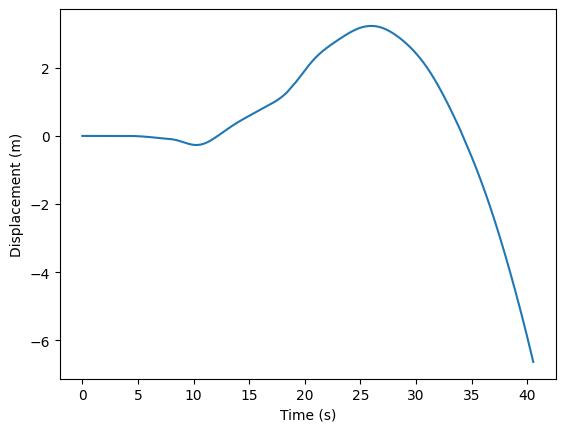

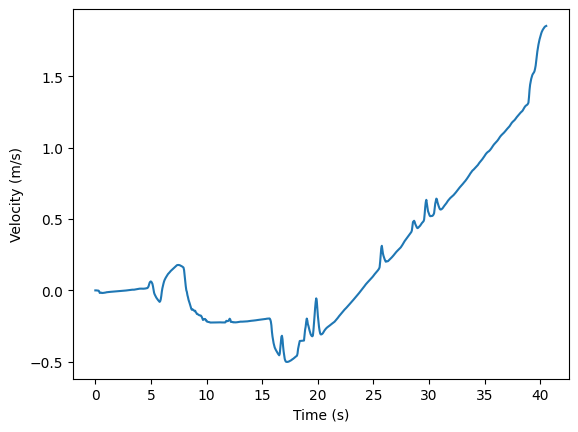

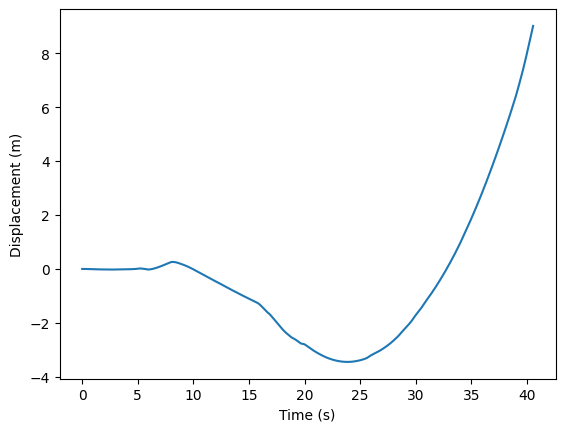

In [33]:
def create_v_d(accs,imus):
    window=0
    iterator=0
    value=0
    vels=[]
    prev_time=imus.iloc[0]["Timestamp"]
    
    prev_acc=0
    prev_vel=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        vel_d=0.5*(prev_acc+x[accs]-2*bias)*(x["Timestamp"]-prev_time)
        #vel=vel_d
        vel=prev_vel+vel_d
        prev_vel=vel
        prev_time=x["Timestamp"]
        prev_acc=x[accs]
        vels.append(vel)
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Velocity (m/s)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),vels)
    i=0
    prev_s=0
    prev_v=0
    prev_time=imus.iloc[0]["Timestamp"]
    dists=[]
    window=0
    iterator=0
    for x in imus.iloc:
        bias=imus.iloc[window][accs]
            #Avg acc * dt = dv
        s=prev_s+vels[i]*(x["Timestamp"]-prev_time)+0.5*0.5*(prev_acc+x[accs]-2*bias)*np.square(x["Timestamp"]-prev_time)
        #s=prev_s+(vels[i])*(x["Timestamp"]-prev_time)
        prev_s=s
        prev_vel=vels[i]
        prev_acc=x[accs]
        prev_time=x["Timestamp"]
        dists.append(s)
        i+=1
        iterator+=1
        if(value!=0):
            if(iterator%value==0):
                window+=value
    plt.figure()
    plt.ylabel("Displacement (m)")
    plt.xlabel("Time (s)")
    plt.plot(np.array(imus.iloc[:]["Timestamp"]-imus["Timestamp"][0]),dists)
    return vels,dists
#z_v,z_d=create_v_d("IMU_Raw_z",df2)
#y_v,y_d=create_v_d("IMU_Raw_y",df2)
#x_v,x_d=create_v_d("IMU_Raw_x",df2)
#z_v_st,z_d_st=create_v_d("IMU_Linear_Acc_Z",df2_st)
#y_v_st,y_d_st=create_v_d("IMU_Linear_Acc_Y",df2_st)
#x_v_st,x_d_st=create_v_d("IMU_Linear_Acc_X",df2_st)
x_v_nt_st,x_d_nt_st=create_v_d("Filtered_X",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_X",trial)

x_v_nt_st,x_d_nt_st=create_v_d("Filtered_Y",trial)

y_v_nt_st,y_d_nt_st=create_v_d("IMU_Linear_Acc_Y",trial)

#z_v_nt_st,z_d_nt_st=create_v_d("IMU_Linear_Acc_Z",trial)

In [35]:
trial2=pd.read_csv(imus[2])

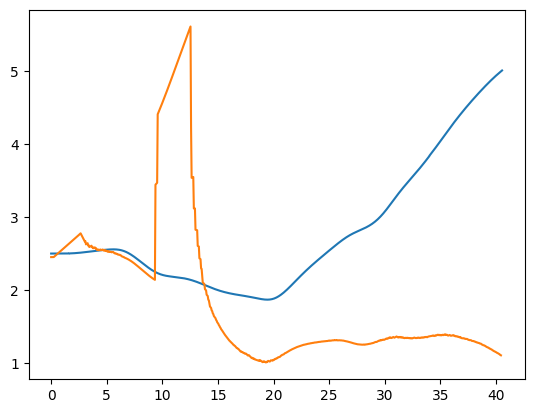

In [36]:
plt.plot(trial["Timestamp"]-trial["Timestamp"][0],trial["Pose_X"]+2.5)
plt.plot(trial2["Timestamp"]-trial2["Timestamp"][0],trial2["Pose_X"])

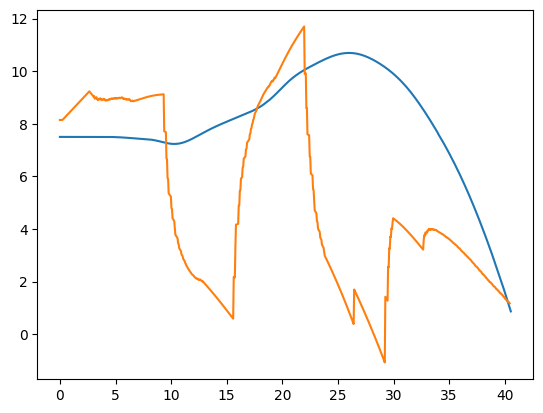

In [37]:
plt.plot(trial["Timestamp"]-trial["Timestamp"][0],trial["Pose_Y"]+7.5)
plt.plot(trial2["Timestamp"]-trial2["Timestamp"][0],trial2["Pose_Y"])

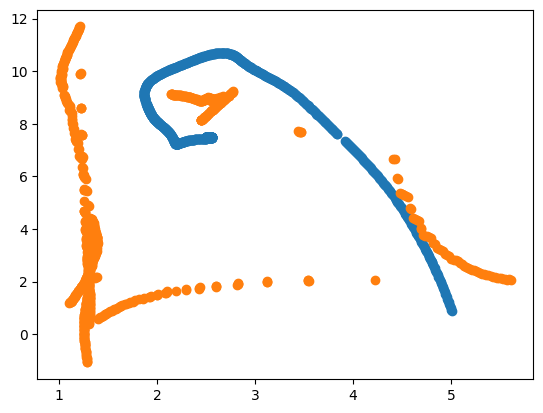

In [38]:
plt.scatter(trial["Pose_X"]+2.5,trial["Pose_Y"]+7.5)
plt.scatter(trial2["Pose_X"],trial2["Pose_Y"])

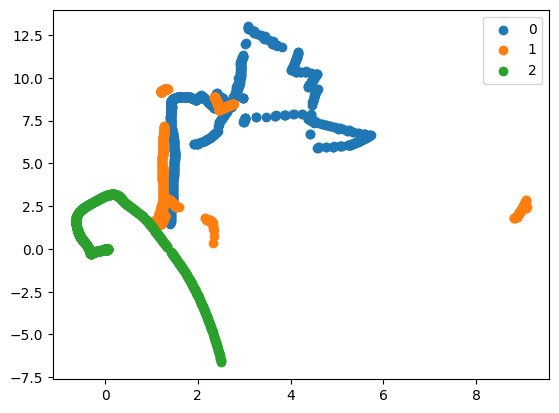

In [73]:
iterator=0
for file in imus[5:]:
    df=pd.read_csv(file)
    plt.scatter(df["Pose_X"],df["Pose_Y"],label=iterator)
    iterator+=1
plt.legend()

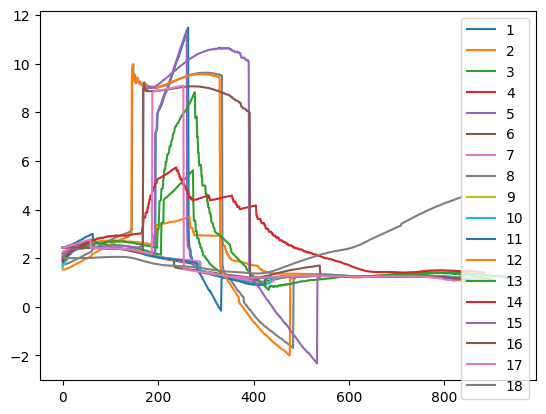

In [214]:
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        plt.plot(df["Pose_X"],label=iterator+1)
    else:
        plt.plot(df["Pose_X"]+2,label=iterator+1)
    iterator+=1
plt.legend()

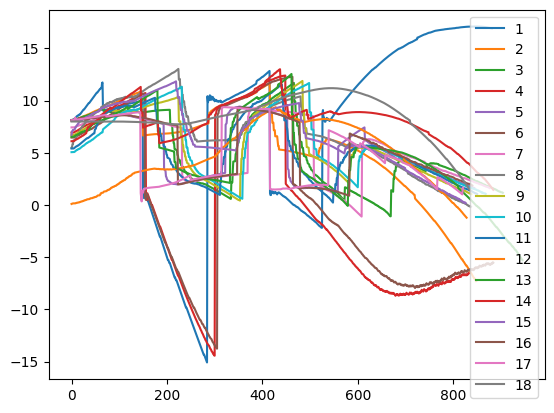

In [215]:
iterator=0
for file in imus[:]:
    df=pd.read_csv(file)
    if(iterator<len(imus)-1):
        plt.plot(df["Pose_Y"],label=iterator+1)
    else:
        plt.plot(df["Pose_Y"]+8,label=iterator+1)
    iterator+=1
plt.legend()

In [269]:
imus

['/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition10_1_2026_04_02_15_43_08.bag/output_IMU_case_Condition10_1_2026_04_02_15_43_08.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition10_2026_04_02_15_35_57.bag/output_IMU_case_Condition10_2026_04_02_15_35_57.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition11_2026_04_02_15_47_28.bag/output_IMU_case_Condition11_2026_04_02_15_47_28.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition12_2026_04_02_15_54_25.bag/output_IMU_case_Condition12_2026_04_02_15_54_25.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition13_2026_04_02_16_02_05.bag/output_IMU_case_Condition13_2026_04_02_16_02_05.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition15_2026_04_02_16_13_14.bag/output_IMU_case_Condition15_2026_04_02_16_13_14.bag.csv',
 '/home/saab/Desktop/2024_UWR/Analys

In [270]:
test=[imus[5],imus[-2]]
print(test)

['/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition15_2026_04_02_16_13_14.bag/output_IMU_case_Condition15_2026_04_02_16_13_14.bag.csv', '/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Default_2026_04_01_14_26_25.bag/output_IMU_case_Default_2026_04_01_14_26_25.bag.csv']


/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Condition15_2026_04_02_16_13_14.bag/output_IMU_case_Condition15_2026_04_02_16_13_14.bag.csv
/home/saab/Desktop/2024_UWR/Analysis/2026_article/1302_Thruster/Default_2026_04_01_14_26_25.bag/output_IMU_case_Default_2026_04_01_14_26_25.bag.csv


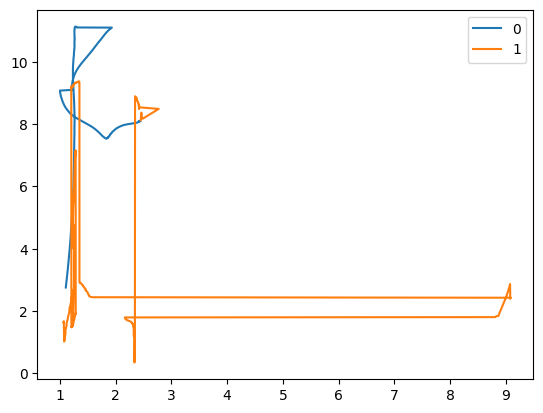

In [271]:
iterator=0
for file in test[:]:
    print(file)
    df=pd.read_csv(file)
    plt.plot(df["Pose_X"],df["Pose_Y"],label=iterator)
    iterator+=1
plt.legend()

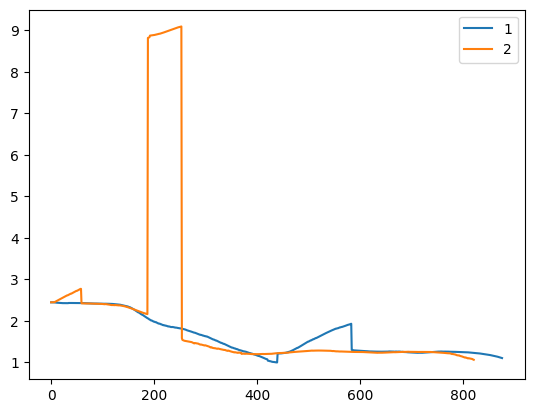

In [272]:
iterator=0
for file in test[:]:
    df=pd.read_csv(file)
    if(iterator<len(test)-1):
        plt.plot(df["Pose_X"],label=iterator+1)
    else:
        plt.plot(df["Pose_X"],label=iterator+1)
    iterator+=1
plt.legend()

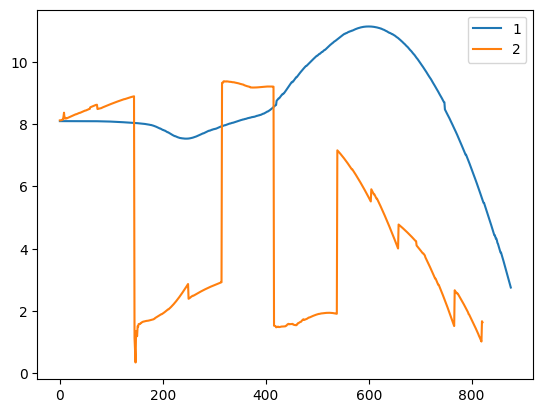

In [273]:
iterator=0
for file in test[:]:
    df=pd.read_csv(file)
    if(iterator<len(test)-1):
        plt.plot(df["Pose_Y"],label=iterator+1)
    else:
        plt.plot(df["Pose_Y"],label=iterator+1)
    iterator+=1
plt.legend()